#### Analysis of features for SAFEX commodities - CTA strategy
Purpose of this notebook: Run IC matrix across features, check feature correlation and parameter sweeps

Feature functions live in `src/features.py`, screening and plots in `src/utilities.py`,
the model in `src/model.py`.

In [13]:
import sys
from pathlib import Path

%load_ext autoreload
%autoreload 2

# Put the project root and src/ on the path so the modules below import
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.append(str(ROOT))
sys.path.append(str(ROOT / "src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import features
import utilities
import model

from theme import set_theme
set_theme()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


{'rc_params': {'figure.facecolor': '#282c34',
  'axes.facecolor': '#282c34',
  'savefig.facecolor': '#282c34',
  'axes.edgecolor': '#3e4451',
  'axes.labelcolor': '#abb2bf',
  'text.color': '#abb2bf',
  'xtick.color': '#abb2bf',
  'ytick.color': '#abb2bf',
  'axes.grid': True,
  'grid.color': '#3e4451',
  'grid.linewidth': 0.6,
  'grid.linestyle': '-',
  'font.size': 9},
 'palette': ['#61afef', '#98c379', '#e5c07b', '#d19a66', '#c678dd', '#e06c75']}

### 1. Load

In [14]:
# Set path
path = ROOT / "data" / "processed" / "df_combined.parquet"

# Read df
df = pd.read_parquet(path)
df.columns

Index(['expiry', 'trade_date', 'contract', 'expiry_month',
       'safex_zar_per_tonne', 'safex_volume', 'safex_open_interest',
       'source_file', 'raw_symbol', 'cbot_usd_per_tonne', 'cbot_volume',
       'staleness_hours', 'usdzar', 'safex_usd_per_tonne', 'ym_corn_arb',
       'log_safex_usd', 'log_safex_zar', 'log_cbot', 'ym_corn_arb_log',
       'arb_z', 'own_z', 'cbot_z', 'vol', 'yw_spread', 'yw_z', 'yw_change',
       'wm_zar_per_tonne', 'wm_usd_per_tonne', 'wm_corn_arb', 'wm_arb_z',
       'fwd_zar_1', 'fwd_usd_1', 'fwd_arb_1', 'fwd_zar_3', 'fwd_usd_3',
       'fwd_arb_3', 'fwd_zar_5', 'fwd_usd_5', 'fwd_arb_5', 'fwd_zar_10',
       'fwd_usd_10', 'fwd_arb_10', 'fwd_zar_21', 'fwd_usd_21', 'fwd_arb_21'],
      dtype='str')

### 2. Feature matrix

Log returns are taken within expiry so no return spans a roll, then summed back up
into a continuous log price (`clog_`). Every feature below is built on that.

In [38]:
# Build dataframe
feat = df.copy()
to_keep = ["expiry", "trade_date", "contract", "expiry_month", "safex_zar_per_tonne", "safex_volume",
           "safex_open_interest", "cbot_usd_per_tonne", "usdzar", "safex_usd_per_tonne", "ym_corn_arb",
           "yw_spread", "yw_z", "wm_zar_per_tonne", "wm_usd_per_tonne"]
feat = feat[to_keep]

contract_cols = ["safex_zar_per_tonne", "safex_usd_per_tonne", "cbot_usd_per_tonne",
                 "wm_zar_per_tonne", "wm_usd_per_tonne"]
spot_cols = ["usdzar"]
spread_cols = ["ym_corn_arb", "yw_spread"]

# Build log returns and pct returns on columns
feat = features.build_log_returns(feat, contract_cols, spot_cols, spread_cols)
feat.filter(like="clog_").head()

,clog_safex_zar_per_tonne,clog_safex_usd_per_tonne,clog_cbot_usd_per_tonne,clog_wm_zar_per_tonne,clog_wm_usd_per_tonne,clog_usdzar
dt,,,,,,
2010-06-07,7.022868,4.969809,4.889356,6.982863,4.929804,2.053059
2010-06-08,6.997596,4.943472,4.887874,6.949856,4.895733,2.054124
2010-06-09,6.993015,4.946394,4.888615,6.948897,4.902276,2.046621
2010-06-10,7.006695,4.959712,4.889356,6.964136,4.917153,2.046983
2010-06-11,7.015712,4.973493,4.906978,6.973543,4.931323,2.042220


### 3. Build the features

In [95]:
# Determine variables
PRICE = "c_ym_corn_arb"   # continuous arb
MA_WINDOWS = [20, 50, 100, 200]
VOL_WINDOWS = [10, 20, 60, 120]
HORIZONS = [1, 2, 3, 4, 5, 10, 15, 20]
CROSS_PAIRS = [(20, 50), (50, 100)]
ABOVE_WINDOWS = [10, 20]

# Build features
feat = features.moving_avg_feat(feat, PRICE, windows=MA_WINDOWS, z_window=120)
feat = features.ma_momentum_feat(feat, PRICE, cross_pairs=CROSS_PAIRS, above_windows=ABOVE_WINDOWS)
feat = features.seasonality_feat(feat)
feat = features.vol_regime_feat(feat, PRICE, windows=VOL_WINDOWS)
feat = features.volume_feat(feat, "safex_volume")
feat = features.days_to_harvest_feat(feat)
feat = features.forward_horizons(feat, PRICE, horizons=HORIZONS, vol_window=20)

# Add new features.
feature_cols = ([f"{PRICE}_ma_dist_z_{w}" for w in MA_WINDOWS]
                + [f"{PRICE}_macross_{f}_{s}" for f, s in CROSS_PAIRS]
                + [f"{PRICE}_above_ma_{w}" for w in ABOVE_WINDOWS]
                + [f"{PRICE}_macd"]
                + ["season_sin", "season_cos", "days_to_harvest", "vol_regime",
                   "volume_ratio", "volume_trend", "yw_z"])
target_cols = [f"target_{h}_d" for h in HORIZONS]

feat[feature_cols].notna().mean().round(3)

C:\Users\Amin\PycharmProjects\Asia Ags\src\features.py:110: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_above_ma_{window}"] = is_above.rolling(window).mean()


c_ym_corn_arb_ma_dist_z_20      0.965
c_ym_corn_arb_ma_dist_z_50      0.957
c_ym_corn_arb_ma_dist_z_100     0.945
c_ym_corn_arb_ma_dist_z_200     0.919
c_ym_corn_arb_macross_20_50     0.924
c_ym_corn_arb_macross_50_100    0.911
c_ym_corn_arb_above_ma_10       0.998
c_ym_corn_arb_above_ma_20       0.995
c_ym_corn_arb_macd              0.936
season_sin                      1.000
season_cos                      1.000
days_to_harvest                 1.000
vol_regime                      0.906
volume_ratio                    0.786
volume_trend                    0.786
yw_z                            0.950
dtype: float64

### 4. IC screen

Selection runs on the train slice only. If the screen picks winners using all the
data, anything tested later is scoring the selection rather than the signal.

In [148]:
# Screen IC scores, along with t-stats
# Leave real holdout after TRAIN_END - the model in section 9 is only scored
# on folds that start after this date, so selection cannot leak into the score.
TRAIN_END = "2020-12-31"
train = feat.loc[:TRAIN_END]

print(f"train {train.index.min():%Y-%m-%d} to {train.index.max():%Y-%m-%d}  n={len(train)}")
print(f"holdout {len(feat) - len(train)} rows")

rows = []
for target in target_cols:
    horizon = int(target.split("_")[1])
    ic = utilities.ic_rank_spearman(train, feature_cols, target)
    t = utilities.nw_t_stat(train, feature_cols, target, lags=horizon)
    for feature in feature_cols:
        rows.append({"feature": feature, "target": target,
                     "ic": ic.loc[feature, "ic"], "t_nw": t.loc[feature, "t_nw"],
                     "p_nw": t.loc[feature, "p_nw"], "n": ic.loc[feature, "n"]})

screen = pd.DataFrame(rows).astype({"ic": float, "t_nw": float, "p_nw": float, "n": int})

# Best horizon for each feature
best = screen.loc[screen.groupby("feature")["t_nw"].apply(lambda s: s.abs().idxmax())]
best = best.sort_values("t_nw", key=abs, ascending=False)
best.round(4)

train 2010-06-07 to 2020-12-31  n=2572
holdout 1375 rows


,feature,target,ic,t_nw,p_nw,n
108,vol_regime,target_15_d,-0.2672,-4.3075,0.0000,2201
111,yw_z,target_15_d,0.1818,3.0115,0.0026,2376
88,c_ym_corn_arb_macd,target_10_d,0.1016,2.0312,0.0422,2321
0,c_ym_corn_arb_ma_dist_z_20,target_1_d,-0.0384,-1.9298,0.0536,2434
84,c_ym_corn_arb_macross_20_50,target_10_d,0.0994,1.8958,0.0580,2272
30,volume_trend,target_2_d,0.0480,1.8634,0.0624,2050
87,c_ym_corn_arb_above_ma_20,target_10_d,0.0951,1.8562,0.0634,2552
123,days_to_harvest,target_20_d,0.1155,1.8138,0.0697,2552
122,season_cos,target_20_d,-0.1275,-1.7584,0.0787,2552
25,season_sin,target_2_d,-0.0398,-1.6981,0.0895,2552


### 5. IC decay

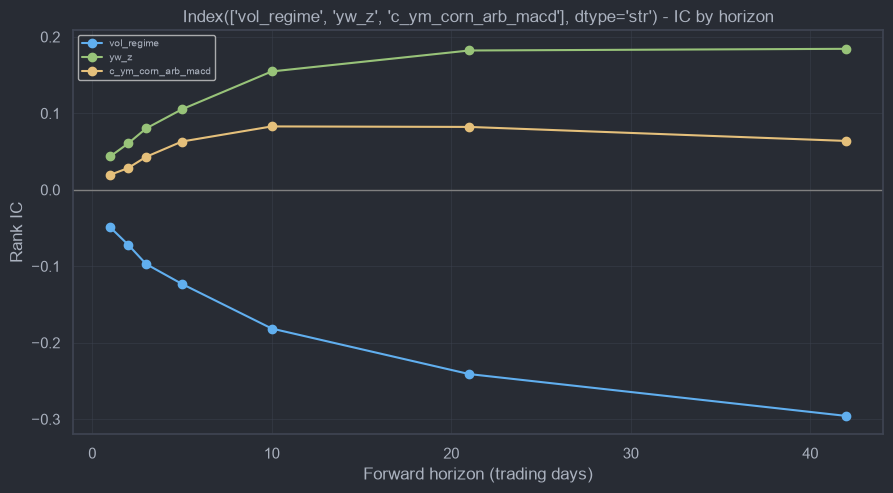

,1,2,3,5,10,21,42
vol_regime,-0.0491,-0.0718,-0.0971,-0.1232,-0.1815,-0.2410,-0.2958
yw_z,0.0436,0.0606,0.0802,0.1053,0.1548,0.1822,0.1844
c_ym_corn_arb_macd,0.0196,0.0284,0.0431,0.0631,0.0829,0.0822,0.0639


In [149]:
# Plot IC decay for a feature
decay_horizons = [1, 2, 3, 5, 10, 21, 42]
decay_feat = features.forward_horizons(feat.copy(), PRICE, horizons=decay_horizons, vol_window=20)

ma_features = [f"{PRICE}_ma_dist_z_{w}" for w in MA_WINDOWS]
feats = feat[["vol_regime", "yw_z", "c_ym_corn_arb_macd"]]
ic_table = utilities.ic_decay(decay_feat, features=feats, horizons=decay_horizons)

utilities.plot_ic_decay(ic_table, title=f"{feats.columns} - IC by horizon")
ic_table.round(4)

### 6. Feature correlation

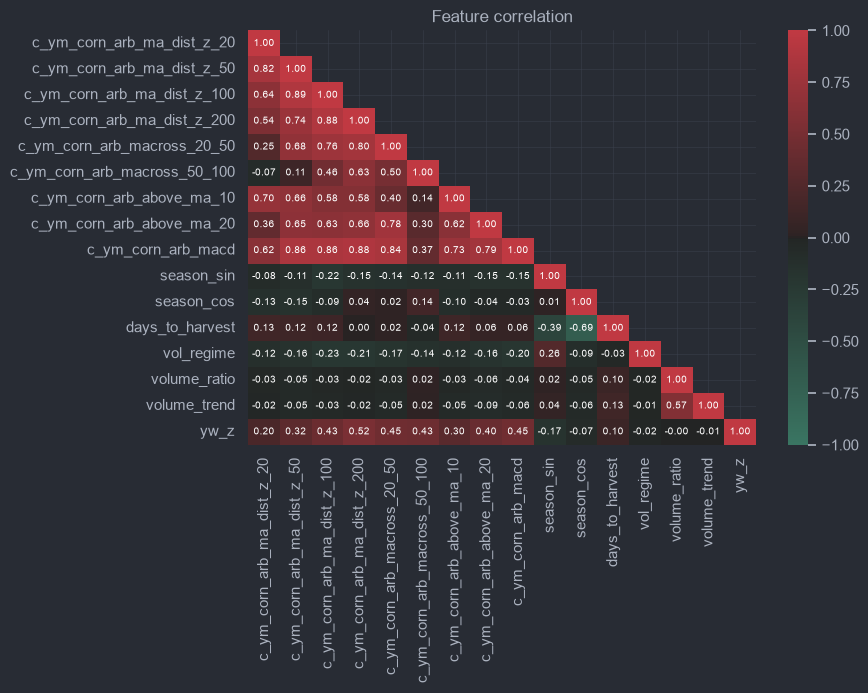

In [150]:
# identify multi-collinearity
corr = utilities.plot_feature_correlation(feat, feature_cols)

### 7. Select

Bonferroni corrects for how many tests were run: more features means a higher bar
for all of them.

In [152]:
from scipy.stats import norm
# Select features based on IC, t-stat and T-Bon
IC_FLOOR = 0.02
T_NOMINAL = 2.0
T_BONFERRONI = abs(norm.ppf(0.025 / len(screen)))

survivors = best[(best["t_nw"].abs() >= T_BONFERRONI) & (best["ic"].abs() >= IC_FLOOR)]
nominal = best[(best["t_nw"].abs() >= T_NOMINAL) & (best["ic"].abs() >= IC_FLOOR)]

print(f"{len(screen)} tests -> bonferroni bar t >= {T_BONFERRONI:.2f}")
print(f"survive bonferroni: {len(survivors)}")
print(f"survive nominal:    {len(nominal)}  {nominal['feature'].tolist()}")
nominal.round(4)

128 tests -> bonferroni bar t >= 3.55
survive bonferroni: 1
survive nominal:    3  ['vol_regime', 'yw_z', 'c_ym_corn_arb_macd']


,feature,target,ic,t_nw,p_nw,n
108,vol_regime,target_15_d,-0.2672,-4.3075,0.0000,2201
111,yw_z,target_15_d,0.1818,3.0115,0.0026,2376
88,c_ym_corn_arb_macd,target_10_d,0.1016,2.0312,0.0422,2321


### 8. Multicollinearity prune

In [157]:
CORR_BAR = 0.7

candidates = nominal.sort_values("t_nw", key=abs, ascending=False)["feature"].tolist()
cand_corr = utilities.feature_correlation(train, candidates).abs()

# Walk the list strongest first, keep a feature only if it is not a near-duplicate
# of one already kept.
kept = []
for candidate in candidates:
    is_duplicate = False
    for already_kept in kept:
        if cand_corr.loc[candidate, already_kept] >= CORR_BAR:
            is_duplicate = True
            print(f"dropped {candidate} (corr {cand_corr.loc[candidate, already_kept]:.2f} with {already_kept})")
    if not is_duplicate:
        kept.append(candidate)

print()
print(f"kept {len(kept)} of {len(candidates)}")
kept


kept 3 of 3


['vol_regime', 'yw_z', 'c_ym_corn_arb_macd']

### 9. Model

`grid=None` uses the default hyperparameters. Pass a grid to switch the inner
validation loop on - it picks parameters inside each fold's training data only.

In [158]:
# Build target and horizon - These need to match to ensure no leakage
TARGET = "target_15_d"
HORIZON = int(TARGET.split("_")[1])
#ONE_FEAT = ["clog_safex_zar_per_tonne_ma_dist_z_20"]

data = feat[kept + [TARGET]].dropna()
X = data[kept]
y = data[TARGET]

# Row number where the holdout starts. Folds testing before this are dropped,
# because the screen already saw that period when it chose the features.
holdout_start = data.index.searchsorted(pd.Timestamp(TRAIN_END))
print(f"holdout starts at row {holdout_start} of {len(data)}")

#grid = model.param_grid({"max_depth": [2, 10], "learning_rate": [0.03, 0.5]})

# Build model
result = model.run_walk_forward(X, y, n_splits=5, embargo=HORIZON, kind="regressor", grid=None,
                                min_test_start=holdout_start)

print(result["summary"])
result["folds"].round(4)

holdout starts at row 2147 of 3508
{'mean_oos_ic': 0.1333690054023402, 'folds_positive': 3, 'n_folds': 3, 'ic_std': 0.09496065246408857}


,fold,train_end,test_start,test_end,n_train,n_test,oos_ic,params,feat_rank,importance
0,0,2022-03-17,2022-04-11,2023-09-22,2443,350,0.1240,"{'n_estimators': 300, 'max_depth': 3, 'learnin...","[vol_regime, yw_z, c_ym_corn_arb_macd]","[0.43725634, 0.26200572, 0.30073795]"
1,1,2023-08-31,2023-09-26,2025-03-05,2793,350,0.2327,"{'n_estimators': 300, 'max_depth': 3, 'learnin...","[vol_regime, yw_z, c_ym_corn_arb_macd]","[0.40504435, 0.27611628, 0.3188394]"
2,2,2025-02-11,2025-03-06,2026-08-11,3143,350,0.0435,"{'n_estimators': 300, 'max_depth': 3, 'learnin...","[vol_regime, yw_z, c_ym_corn_arb_macd]","[0.40604112, 0.30131713, 0.2926418]"


### 10. Performance

In [159]:
# Performance metrics
forward_return = (feat[PRICE].shift(-HORIZON) - feat[PRICE])

oos = result["predictions"].rename("pred").to_frame()
oos["fwd_raw"] = forward_return.reindex(oos.index)
oos = oos.dropna()

# The arb target is in USD/tonne, so divide by the underlying price to turn each
# trade into a percentage. That is what makes these stats comparable to any
# other product. For a log-return target, drop notional and pass log_returns=True.
notional = feat["safex_usd_per_tonne"].reindex(oos.index)

# Pass the full overlapping sample - horizon does the thinning, and averages
# over every starting offset so the answer is not an accident of where we began.
stats = model.performance_stats(oos["pred"], oos["fwd_raw"], 252 / HORIZON, notional=notional, horizon=HORIZON)

pd.Series(stats).round(4)

n                    70.0000
win_rate              0.5819
ev_pct                0.0086
median_pct            0.0101
avg_win_pct           0.0404
avg_loss_pct         -0.0357
total_return_pct      0.7853
annual_return_pct     0.1373
max_draw_down_pct    -0.2638
sharpe                0.7545
sortino               1.3522
calmar                0.5964
t_stat                1.5402
n_offsets            15.0000
sharpe_min           -0.3155
sharpe_max            1.5021
dtype: float64

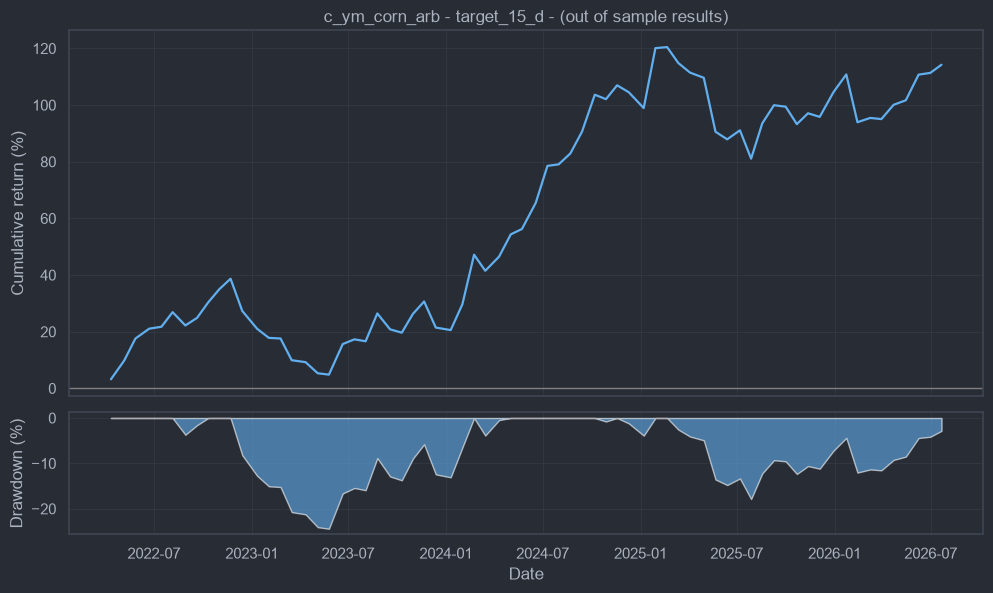

pooled OOS rank IC: 0.1239


In [160]:
# Equity curve, in percent
sample = oos.iloc[::HORIZON]
pnl = np.sign(sample["pred"]) * sample["fwd_raw"]
trade_returns = model.to_simple_returns(pnl, notional=notional.reindex(sample.index))

equity = utilities.plot_equity_curve(trade_returns, title=f"{PRICE} - {TARGET} - (out of sample results)")

scores = model.score_predictions(oos["pred"], oos["fwd_raw"])
print(f"pooled OOS rank IC: {scores:.4f}")